# Strategy S4 — Annotator-Agreement Upsampling
## Thesis: Synthetic Data Augmentation for SHROOM-visions

**Core idea**: 71.7% of spans have `prob=0.333` (only 1/3 annotators agreed — high label noise).  
The 7.4% of spans with `prob=1.0` (all annotators agreed) represent **unambiguous hallucinations** —  
the clearest training signal. Upsampling these samples gives the model a stronger learning gradient  
for decisive hallucination cases without requiring any external API or generation.

**From analysis notebook (S4 insight)**:
- prob=0.333 (1/3 agreed): 71.7% of spans — noisy, borderline
- prob=0.667 (2/3 agreed): 20.4% of spans — moderate
- prob=1.000 (all agreed):  7.4% of spans — clear signal ← **upsample these**

**Implementation**: No generation, no external APIs.
- Tier 1 (any span prob=1.0): duplicate `UPSAMPLE_HIGH` times
- Tier 2 (any span prob=0.667, none prob=1.0): duplicate `UPSAMPLE_MED` times
- Tier 3 (all spans prob=0.333): keep as-is (1x)

**Expected gain**: 2–4% Span IoU improvement from cleaner decision boundaries.

---
**Comparison**: Results are compared to `ft_predictions/baseline_results.csv` (real data only).

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
    "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git", "--quiet"], check=False)
subprocess.run([sys.executable, "-m", "pip", "install",
    "--no-deps", "trl", "peft", "accelerate", "bitsandbytes", "--quiet"], check=False)
subprocess.run([sys.executable, "-m", "pip", "install",
    "qwen-vl-utils", "transformers>=4.45.0", "scipy", "scikit-learn",
    "matplotlib", "seaborn", "--quiet"], check=False)
print('Installation complete.')

Installation complete.


In [ ]:
import json, re, os, io, difflib, random, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from typing import Optional
from scipy.stats import spearmanr
from tqdm.auto import tqdm
import torch
from datasets import Dataset
from PIL import Image
from qwen_vl_utils import process_vision_info
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')

CUDA: True
GPU : NVIDIA A100-SXM4-40GB


In [ ]:
# ── Base config (same as baseline) ────────────────────────────────────────────
MODEL_ID        = 'unsloth/Qwen2-VL-2B-Instruct'
LORA_R          = 16; LORA_ALPHA = 16; LORA_DROPOUT = 0.0
NUM_EPOCHS      = 2;  LR = 2e-4;  BATCH_SIZE = 1;  GRAD_ACCUM = 8
WARMUP_STEPS    = 50; MAX_SEQ_LEN = 2048; MAX_NEW_TOKENS = 512
SAVE_STEPS      = 200; LOG_STEPS = 10
TRAIN_LANGS     = ['en', 'fr', 'it', 'zh']
VAL_FRACTION    = 0.10; RANDOM_SEED = 42; MAX_VAL_SAMPLES = 200

# ── S4-specific config ─────────────────────────────────────────────────────────
STRATEGY        = 'S4_AgreementUpsampling'
UPSAMPLE_HIGH   = 4   # samples with any span prob=1.0
UPSAMPLE_MED    = 2   # samples with any span prob=0.667

# ── Paths ─────────────────────────────────────────────────────────────────────
from google.colab import drive; drive.mount('/content/drive')
DRIVE_BASE        = Path('/content/drive/MyDrive/shroom-visions')
DATA_DIR          = DRIVE_BASE / 'distrib'
IMAGE_DIR         = DRIVE_BASE / 'shroom-vis-images'
OUTPUT_DIR        = DRIVE_BASE / f'ft_predictions_{STRATEGY}'
CKPT_DIR          = DRIVE_BASE / f'ft_checkpoints_{STRATEGY}'
BASELINE_CSV      = DRIVE_BASE / 'ft_predictions' / 'baseline_results.csv'
SYNTH_CACHE       = DRIVE_BASE / f'synth_cache_{STRATEGY}.json'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER  = ['invention', 'mischaracterization', 'OCR', 'miscounting', 'other']
VALID_LABELS = set(LABEL_ORDER)
LANGUAGES    = ['en', 'fr', 'it', 'zh']
LANG_NAMES   = {'en': 'English', 'fr': 'French', 'it': 'Italian', 'zh': 'Chinese'}

random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
print(f'Strategy      : {STRATEGY}')
print(f'UPSAMPLE HIGH : {UPSAMPLE_HIGH}x  |  MED: {UPSAMPLE_MED}x')
print(f'Cache         : {SYNTH_CACHE}')

Mounted at /content/drive
Strategy      : S4_AgreementUpsampling
UPSAMPLE HIGH : 4x  |  MED: 2x
Cache         : /content/drive/MyDrive/shroom-visions/synth_cache_S4_AgreementUpsampling.json


In [ ]:
def load_jsonl(path):
    return [json.loads(l) for l in path.read_text(encoding='utf-8').splitlines() if l.strip()]

train_raw, test_raw = {}, {}
for lang in LANGUAGES:
    train_raw[lang] = load_jsonl(DATA_DIR / f'shroom-vision.train.{lang}.labeled.jsonl')
    test_raw[lang]  = load_jsonl(DATA_DIR / f'shroom-vision.test.{lang}.unlabeled.jsonl')
    print(f'{lang.upper()}: {len(train_raw[lang])} train | {len(test_raw[lang])} test')

EN: 3799 train | 1201 test
FR: 3767 train | 1233 test
IT: 3746 train | 1254 test
ZH: 3790 train | 1210 test


---
## Strategy S4 — Agreement Upsampling

We classify each training sample by its highest annotator agreement level,  
then duplicate high-certainty samples to give the model stronger training signal.

In [ ]:
def certainty_tier(sample):
    """Return 2=high (any prob=1.0), 1=medium (any prob=0.667), 0=low."""
    labels = sample.get('labels', [])
    if not labels:
        return -1  # clean
    probs = [lb['prob'] for lb in labels]
    if any(p >= 1.0 for p in probs):
        return 2
    if any(p >= 0.667 for p in probs):
        return 1
    return 0

tier_counts = {lang: Counter() for lang in LANGUAGES}
for lang in LANGUAGES:
    for s in train_raw[lang]:
        tier_counts[lang][certainty_tier(s)] += 1

print('Tier distribution per language:')
print(f'{"Lang":6s} {"clean":>8s} {"low(0.333)": >12s} {"med(0.667)": >12s} {"high(1.0)": >10s}')
for lang in LANGUAGES:
    tc = tier_counts[lang]
    print(f'{lang.upper():6s} {tc[-1]:>8d} {tc[0]:>12d} {tc[1]:>12d} {tc[2]:>10d}')

Tier distribution per language:
Lang      clean   low(0.333)   med(0.667)  high(1.0)
EN          962         2133            1        703
FR          964         2321            1        481
IT          986         2108            1        651
ZH         1383         1854            0        553


In [ ]:
def _load_synth_cache():
    if SYNTH_CACHE.exists():
        print(f'Loading cache: {SYNTH_CACHE}')
        return json.loads(SYNTH_CACHE.read_text(encoding='utf-8'))
    return None

def _save_synth_cache(data):
    SYNTH_CACHE.parent.mkdir(parents=True, exist_ok=True)
    SYNTH_CACHE.write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'Saved: {SYNTH_CACHE}')

cached = _load_synth_cache()
if cached is not None:
    synthetic_samples = {lang: cached.get(lang, []) for lang in LANGUAGES}
    total = sum(len(v) for v in synthetic_samples.values())
    print(f'Loaded {total} synthetic samples from cache — skipping generation.')
else:
    synthetic_samples = {lang: [] for lang in LANGUAGES}

    for lang in LANGUAGES:
        for s in train_raw[lang]:
            tier = certainty_tier(s)
            factor = UPSAMPLE_HIGH if tier == 2 else UPSAMPLE_MED if tier == 1 else 0
            for i in range(factor - 1):   # -1: original already in real data
                copy = dict(s)
                copy['id'] = f'synth_s4_t{tier}_r{i}_{s["id"]}'
                synthetic_samples[lang].append(copy)

        real_n  = len(train_raw[lang])
        synth_n = len(synthetic_samples[lang])
        total_n = real_n + synth_n
        print(f'{lang.upper()}: real={real_n:,}  +synthetic={synth_n:,}  → total={total_n:,}  ({synth_n/real_n*100:.0f}% augmentation)')

    _save_synth_cache(synthetic_samples)

Loading cache: /content/drive/MyDrive/shroom-visions/synth_cache_S4_AgreementUpsampling.json
Loaded 7167 synthetic samples from cache — skipping generation.


In [ ]:
# Label distribution in synthetic samples vs original
print('Label distribution — REAL vs REAL+SYNTHETIC (EN):')
real_cnt  = Counter(lb['label'] for s in train_raw['en'] for lb in s.get('labels', []))
synth_cnt = Counter(lb['label'] for s in synthetic_samples['en'] for lb in s.get('labels', []))
combined_cnt = {cat: real_cnt.get(cat,0) + synth_cnt.get(cat,0) for cat in LABEL_ORDER}

print(f'{"Category":22s} {"Real":>8s} {"Synthetic":>10s} {"Combined":>10s} {"Ratio":>8s}')
for cat in LABEL_ORDER:
    r, s, c = real_cnt.get(cat,0), synth_cnt.get(cat,0), combined_cnt[cat]
    print(f'{cat:22s} {r:>8d} {s:>10d} {c:>10d} {c/r:.2f}x')

Label distribution — REAL vs REAL+SYNTHETIC (EN):
Category                   Real  Synthetic   Combined    Ratio
invention                  5204       5402      10606 2.04x
mischaracterization        5688       5108      10796 1.90x
OCR                         602        927       1529 2.54x
miscounting                 999       1527       2526 2.53x
other                       401        170        571 1.42x


In [ ]:
def resolve_image_path(image_name, image_dir):
    p = image_dir / image_name
    if p.exists(): return p
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
        alt = p.with_suffix(ext)
        if alt.exists(): return alt
    return None

INSTRUCTION = """Identify all hallucinated text spans in the vision model's response.
A hallucination is text that is factually incorrect compared to what is actually visible in the image.

Categories:
- invention: entities or facts completely absent from the image
- mischaracterization: visible content described incorrectly
- OCR: text visible in the image is misread or mistranscribed
- miscounting: wrong quantity of visible items
- other: hallucination not fitting the above

Return ONLY a JSON array:
[{"text": "<exact text copied from the response>", "prob": <0.0-1.0>, "label": "<category>"}]
If there are no hallucinations, return: []"""

def build_conversation(sample, image_dir):
    img_path = resolve_image_path(sample['image_name'], image_dir)
    if img_path is None: return None
    response = sample['response']
    labels   = sample.get('labels', [])
    target_spans = []
    for lb in sorted(labels, key=lambda x: x['start']):
        span_text = response[lb['start']:lb['end']]
        if span_text.strip():
            target_spans.append({'text': span_text, 'prob': round(float(lb['prob']), 4), 'label': lb['label']})
    target_json = json.dumps(target_spans, ensure_ascii=False)
    user_text = f"{INSTRUCTION}\n\nQuestion asked: {sample['prompt']}\n\nVLM response to analyse:\n{response}"
    return {
        'messages': [
            {'role': 'user', 'content': [
                {'type': 'image', 'image': str(img_path)},
                {'type': 'text',  'text':  user_text},
            ]},
            {'role': 'assistant', 'content': [{'type': 'text', 'text': target_json}]},
        ],
        '_id': sample['id'], '_lang': sample.get('language',''),
        '_response': response, '_labels': labels,
    }

def build_inference_conversation(sample, image_dir):
    img_path = resolve_image_path(sample['image_name'], image_dir)
    if img_path is None: return None
    user_text = f"{INSTRUCTION}\n\nQuestion asked: {sample['prompt']}\n\nVLM response to analyse:\n{sample['response']}"
    return {
        'messages': [{'role': 'user', 'content': [
            {'type': 'image', 'image': str(img_path)},
            {'type': 'text',  'text':  user_text},
        ]}],
        '_id': sample['id'], '_lang': sample.get('language',''),
        '_response': sample['response'], '_labels': sample.get('labels', []),
    }

print('Conversation builders ready.')

Conversation builders ready.


In [ ]:
all_train_convs, all_val_convs = [], []
skipped_total = 0

for lang in TRAIN_LANGS:
    # Val split from REAL data only (same split as baseline for fair comparison)
    samples = train_raw[lang]
    hallu = [s for s in samples if s.get('labels')]
    clean = [s for s in samples if not s.get('labels')]
    h_tr, h_val = train_test_split(hallu, test_size=VAL_FRACTION, random_state=RANDOM_SEED)
    c_tr, c_val = train_test_split(clean, test_size=VAL_FRACTION, random_state=RANDOM_SEED)

    # Training = real train split + synthetic samples
    lang_train = h_tr + c_tr + synthetic_samples[lang]
    lang_val   = h_val + c_val

    skipped = 0
    for s in lang_train:
        conv = build_conversation(s, IMAGE_DIR)
        if conv: all_train_convs.append(conv)
        else: skipped += 1
    for s in lang_val:
        conv = build_inference_conversation(s, IMAGE_DIR)
        if conv: all_val_convs.append(conv)
        else: skipped += 1
    skipped_total += skipped

    print(f'{lang.upper()}: {len(lang_train)} train (real+synth) | {len(lang_val)} val | {skipped} skipped')

random.shuffle(all_train_convs)
print(f'\nTotal train: {len(all_train_convs):,}  |  Total val: {len(all_val_convs):,}')

EN: 5528 train (real+synth) | 381 val | 0 skipped
FR: 4833 train (real+synth) | 378 val | 0 skipped
IT: 5325 train (real+synth) | 375 val | 0 skipped
ZH: 5069 train (real+synth) | 380 val | 0 skipped

Total train: 20,755  |  Total val: 1,514


---
## Model Loading & Training
(Identical pipeline to baseline notebook)

In [ ]:
from unsloth import FastVisionModel, is_bf16_supported
print(f'Loading {MODEL_ID} in 4-bit...')
model, processor = FastVisionModel.from_pretrained(
    MODEL_ID, load_in_4bit=True, use_gradient_checkpointing='unsloth')
print('Base model loaded.')
if torch.cuda.is_available():
    print(f'VRAM: {torch.cuda.memory_allocated()/1e9:.1f} / {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading unsloth/Qwen2-VL-2B-Instruct in 4-bit...
==((====))==  Unsloth 2026.5.10: Fast Qwen2_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

Skipping model.language_model.layers.1.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.down_proj: no quant_state found
Base model loaded.
VRAM: 2.5 / 42.4 GB


In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=False, finetune_language_layers=True,
    finetune_attention_modules=True, finetune_mlp_modules=True,
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    bias='none', random_state=RANDOM_SEED,
)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable/1e6:.2f}M / {total/1e6:.1f}M ({trainable/total*100:.2f}%)')

Trainable: 18.46M / 1566.8M (1.18%)


In [ ]:
from trl import SFTTrainer, SFTConfig
from unsloth.trainer import UnslothVisionDataCollator

hf_train = Dataset.from_list([{'messages': c['messages']} for c in all_train_convs])
print(f'HF training dataset: {len(hf_train):,} samples')

steps_per_epoch = math.ceil(len(hf_train) / (BATCH_SIZE * GRAD_ACCUM))
print(f'Steps/epoch: {steps_per_epoch}  |  Total: {steps_per_epoch*NUM_EPOCHS}')

trainer = SFTTrainer(
    model=model, tokenizer=processor.tokenizer,
    data_collator=UnslothVisionDataCollator(model, processor),
    train_dataset=hf_train,
    args=SFTConfig(
        output_dir=str(CKPT_DIR),
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        warmup_steps=WARMUP_STEPS, learning_rate=LR,
        lr_scheduler_type='cosine',
        fp16=not is_bf16_supported(), bf16=is_bf16_supported(),
        logging_steps=LOG_STEPS, save_steps=SAVE_STEPS, save_total_limit=2,
        optim='adamw_8bit', weight_decay=0.01, seed=RANDOM_SEED,
        report_to='none', remove_unused_columns=False,
        dataset_text_field='', dataset_kwargs={'skip_prepare_dataset': True},
        max_seq_length=MAX_SEQ_LEN,
    ),
)
print('Trainer ready.')

HF training dataset: 20,755 samples
Steps/epoch: 2595  |  Total: 5190
Unsloth: Model does not have a default image size - using 512
Trainer ready.


Training S4_AgreementUpsampling...
Resuming from checkpoint: /content/drive/MyDrive/shroom-visions/ft_checkpoints_S4_AgreementUpsampling/checkpoint-1600


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 20,755 | Num Epochs = 2 | Total steps = 5,190
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 2,227,450,368 (0.83% trained)


Step,Training Loss
1610,0.372714
1620,0.349468
1630,0.447912
1640,0.388699
1650,0.361806
1660,0.399283
1670,0.371084
1680,0.382189
1690,0.335186
1700,0.387863


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S4_AgreementUpsampling/checkpoint-1800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S4_AgreementUpsampling/checkpoint-2000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S4_AgreementUpsampling/checkpoint-2200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S4_AgreementUpsampling/checkpoint-2400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S4_AgreementUpsampling/checkpoint-2600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S4_AgreementUpsampling/checkpoint-2800/tokenizer_config.json.
Unsl

Done! Loss: 0.2000  Runtime: 438.8 min


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S4_AgreementUpsampling/final_adapter/tokenizer_config.json.


Adapter saved → /content/drive/MyDrive/shroom-visions/ft_checkpoints_S4_AgreementUpsampling/final_adapter


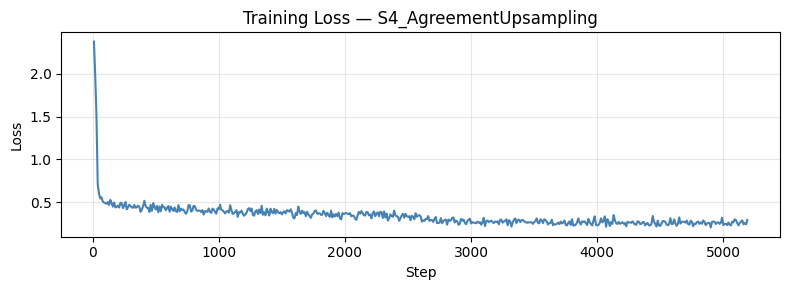

In [ ]:
print(f'Training {STRATEGY}...')
import glob as _glob; _ckpts = sorted(
    _glob.glob(str(CKPT_DIR / 'checkpoint-*')),
    key=lambda x: int(x.split("checkpoint-")[-1])
)
_resume = _ckpts[-1] if _ckpts else False
if _resume: print(f'Resuming from checkpoint: {_resume}')
train_result = trainer.train(resume_from_checkpoint=_resume)
print(f'Done! Loss: {train_result.training_loss:.4f}  Runtime: {train_result.metrics.get("train_runtime",0)/60:.1f} min')
adapter_dir = CKPT_DIR / 'final_adapter'
model.save_pretrained(adapter_dir)
processor.save_pretrained(adapter_dir)
print(f'Adapter saved → {adapter_dir}')

# Loss curve
logs = [e for e in trainer.state.log_history if 'loss' in e]
if logs:
    plt.figure(figsize=(8,3))
    plt.plot([e['step'] for e in logs], [e['loss'] for e in logs], color='steelblue')
    plt.title(f'Training Loss — {STRATEGY}'); plt.xlabel('Step'); plt.ylabel('Loss')
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_loss.png', dpi=150); plt.show()

In [ ]:
FastVisionModel.for_inference(model)
device = next(model.parameters()).device

def run_inference(conv):
    msgs = conv['messages']
    text_input = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(msgs)
    inputs = processor(text=[text_input], images=image_inputs, videos=video_inputs,
                       padding=True, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS,
                             do_sample=False, pad_token_id=processor.tokenizer.pad_token_id)
    generated = out[:, inputs['input_ids'].shape[1]:]
    return processor.batch_decode(generated, skip_special_tokens=True)[0].strip()

LABEL_NORM = {'mischaracterisation':'mischaracterization','ocr_problem':'OCR','ocr problem':'OCR','ocr':'OCR','fabrication':'invention'}

def parse_model_output(raw):
    m = re.search(r'\[.*\]', raw, re.DOTALL)
    if not m: return []
    try: spans = json.loads(m.group())
    except: return []
    out = []
    for sp in spans:
        if not isinstance(sp, dict) or 'text' not in sp: continue
        text  = str(sp['text']).strip()
        if not text: continue
        label = LABEL_NORM.get(str(sp.get('label','other')).lower().strip(), str(sp.get('label','other')).lower().strip())
        if label not in VALID_LABELS: label = 'other'
        prob = max(0.0, min(1.0, float(sp.get('prob', 0.8))))
        out.append({'text': text, 'prob': prob, 'label': label})
    return out

def find_span_pos(response, text):
    if not text: return None
    pos = response.find(text)
    if pos != -1: return pos, pos + len(text)
    pos = response.lower().find(text.lower())
    if pos != -1: return pos, pos + len(text)
    stripped = re.sub(r'[\*\_`]+', '', text).strip()
    if stripped and stripped != text:
        pos = response.lower().find(stripped.lower())
        if pos != -1: return pos, pos + len(stripped)
    if len(text) >= 8:
        tl, rl, tlen = text.lower(), response.lower(), len(text)
        step = max(1, tlen // 4)
        best_r, best_pos = 0.0, 0
        for i in range(0, max(1, len(response)-tlen+1), step):
            r = difflib.SequenceMatcher(None, rl[i:i+tlen], tl).ratio()
            if r > best_r: best_r, best_pos = r, i
        for i in range(max(0, best_pos-step), min(len(response)-tlen+1, best_pos+step+1)):
            r = difflib.SequenceMatcher(None, rl[i:i+tlen], tl).ratio()
            if r > best_r: best_r, best_pos = r, i
        if best_r >= 0.80: return best_pos, best_pos + tlen
    return None

def map_spans_to_positions(response, parsed):
    result, used = [], set()
    for sp in parsed:
        pos = find_span_pos(response, sp['text'])
        if pos is None: continue
        start, end = pos
        if len(set(range(start, end)) & used) > (end-start)*0.5: continue
        result.append({'start': start, 'end': end, 'prob': sp['prob'], 'label': sp['label']})
        used.update(range(start, end))
    return sorted(result, key=lambda x: x['start'])

def predict_one(conv):
    return map_spans_to_positions(conv['_response'], parse_model_output(run_inference(conv)))

print('Inference functions ready.')

Inference functions ready.


In [ ]:
def span_iou(pred, gold):
    p = set(i for s in pred for i in range(s['start'], s['end']))
    g = set(i for s in gold for i in range(s['start'], s['end']))
    if not p and not g: return 1.0
    return len(p & g) / len(p | g)

def spearman_rho(pred, gold, resp_len):
    pa = np.zeros(resp_len); ga = np.zeros(resp_len)
    for s in pred:
        for i in range(s['start'], min(s['end'], resp_len)): pa[i] = max(pa[i], s['prob'])
    for s in gold:
        for i in range(s['start'], min(s['end'], resp_len)): ga[i] = max(ga[i], s['prob'])
    if np.allclose(pa, pa[0]) and np.allclose(ga, ga[0]):
        return 1.0 if np.allclose(pa, ga) else 0.0
    rho, _ = spearmanr(pa, ga)
    return float(rho) if not np.isnan(rho) else 0.0

def category_f1(pred, gold, min_iou=0.3):
    tp, fp, fn = Counter(), Counter(), Counter()
    used_gold, used_pred = set(), set()
    for pi, p in enumerate(pred):
        pc = set(range(p['start'], p['end']))
        best_iou, best_gi = 0.0, -1
        for gi, g in enumerate(gold):
            if gi in used_gold: continue
            gc = set(range(g['start'], g['end']))
            iou = len(pc & gc) / max(len(pc | gc), 1)
            if iou > best_iou: best_iou, best_gi = iou, gi
        if best_iou >= min_iou and best_gi != -1:
            if p['label'] == gold[best_gi]['label']: tp[gold[best_gi]['label']] += 1
            else: fp[p['label']] += 1; fn[gold[best_gi]['label']] += 1
            used_gold.add(best_gi); used_pred.add(pi)
    for pi, p in enumerate(pred):
        if pi not in used_pred: fp[p['label']] += 1
    for gi, g in enumerate(gold):
        if gi not in used_gold: fn[g['label']] += 1
    scores = {}
    for cat in LABEL_ORDER:
        prec = tp[cat] / max(tp[cat]+fp[cat], 1)
        rec  = tp[cat] / max(tp[cat]+fn[cat], 1)
        scores[cat] = 2*prec*rec / max(prec+rec, 1e-9)
    scores['macro'] = float(np.mean(list(scores.values())))
    return scores

def evaluate_predictions(convs, predictions):
    ious, rhos, all_pred, all_gold = [], [], [], []
    for conv in convs:
        gold = conv['_labels']; pred = predictions.get(conv['_id'], [])
        ious.append(span_iou(pred, gold))
        rhos.append(spearman_rho(pred, gold, len(conv['_response'])))
        all_pred.extend(pred); all_gold.extend(gold)
    return {'mean_iou': float(np.mean(ious)), 'mean_spearman': float(np.nanmean(rhos)),
            'cat_f1': category_f1(all_pred, all_gold), 'n': len(convs)}

print('Metric functions ready.')

Metric functions ready.


In [ ]:
import time
val_by_lang = defaultdict(list)
for conv in all_val_convs: val_by_lang[conv['_lang']].append(conv)

val_predictions = {}
for lang, convs in val_by_lang.items():
    convs = convs[:MAX_VAL_SAMPLES]
    print(f'Evaluating {lang.upper()} ({len(convs)} samples)...')
    t0 = time.time()
    for conv in tqdm(convs, desc=lang.upper()):
        try: val_predictions[conv['_id']] = predict_one(conv)
        except Exception as e: print(f'  Error: {e}'); val_predictions[conv['_id']] = []
    print(f'  Done in {(time.time()-t0)/60:.1f} min')

Evaluating EN (200 samples)...


EN:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  Done in 79.9 min
Evaluating FR (200 samples)...


FR:   0%|          | 0/200 [00:00<?, ?it/s]

...

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  Done in 65.9 min
Evaluating ZH (200 samples)...


ZH:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  Done in 50.6 min


In [ ]:
results_by_lang = {}
print('=' * 60)
print(f'VALIDATION RESULTS — {STRATEGY}')
print('=' * 60)
for lang, convs in val_by_lang.items():
    convs = convs[:MAX_VAL_SAMPLES]
    m = evaluate_predictions(convs, val_predictions)
    results_by_lang[lang] = m
    print(f'[{lang.upper()}]  IoU={m["mean_iou"]:.4f}  Spearman={m["mean_spearman"]:.4f}  CatF1={m["cat_f1"]["macro"]:.4f}')

all_val_limited = [c for lc in val_by_lang.values() for c in lc[:MAX_VAL_SAMPLES]]
overall = evaluate_predictions(all_val_limited, val_predictions)
print(f'[OVERALL]  IoU={overall["mean_iou"]:.4f}  Spearman={overall["mean_spearman"]:.4f}  CatF1={overall["cat_f1"]["macro"]:.4f}')

# Save results
rows = []
for lang in LANGUAGES:
    if lang not in results_by_lang: continue
    m = results_by_lang[lang]
    row = {'Language': lang.upper(), 'Span IoU': round(m['mean_iou'],4),
           'Spearman rho': round(m['mean_spearman'],4), 'Cat F1 (macro)': round(m['cat_f1']['macro'],4)}
    for cat in LABEL_ORDER: row[f'F1({cat[:4]})'] = round(m['cat_f1'].get(cat,0.0),4)
    rows.append(row)
row_all = {'Language':'OVERALL','Span IoU':round(overall['mean_iou'],4),
           'Spearman rho':round(overall['mean_spearman'],4),'Cat F1 (macro)':round(overall['cat_f1']['macro'],4)}
for cat in LABEL_ORDER: row_all[f'F1({cat[:4]})'] = round(overall['cat_f1'].get(cat,0.0),4)
rows.append(row_all)
results_df = pd.DataFrame(rows)
results_df.to_csv(OUTPUT_DIR / f'{STRATEGY}_results.csv', index=False)
print(f'Saved → {OUTPUT_DIR}/{STRATEGY}_results.csv')

VALIDATION RESULTS — S4_AgreementUpsampling
[EN]  IoU=0.2717  Spearman=0.2982  CatF1=0.2695
[FR]  IoU=0.3368  Spearman=0.3482  CatF1=0.3001
[IT]  IoU=0.3464  Spearman=0.3842  CatF1=0.3560
[ZH]  IoU=0.3561  Spearman=0.3700  CatF1=0.2879
[OVERALL]  IoU=0.3278  Spearman=0.3501  CatF1=0.3096
Saved → /content/drive/MyDrive/shroom-visions/ft_predictions_S4_AgreementUpsampling/S4_AgreementUpsampling_results.csv


COMPARISON: Baseline (real only)  vs  S4_AgreementUpsampling
Language Span IoU (base) Span IoU (S4_AgreementUpsampling) Span IoU Δ Spearman rho (base) Spearman rho (S4_AgreementUpsampling) Spearman rho Δ Cat F1 (macro) (base) Cat F1 (macro) (S4_AgreementUpsampling) Cat F1 (macro) Δ
      EN          0.2493                            0.2717    +0.0224              0.3085                                0.2982        -0.0103                0.2718                                  0.2695          -0.0023
      FR          0.3386                            0.3368    -0.0018              0.3551                                0.3482        -0.0069                0.3364                                  0.3001          -0.0363
      IT          0.3271                            0.3464    +0.0193              0.3797                                0.3842        +0.0045                0.2992                                  0.3560          +0.0568
      ZH          0.3257                           

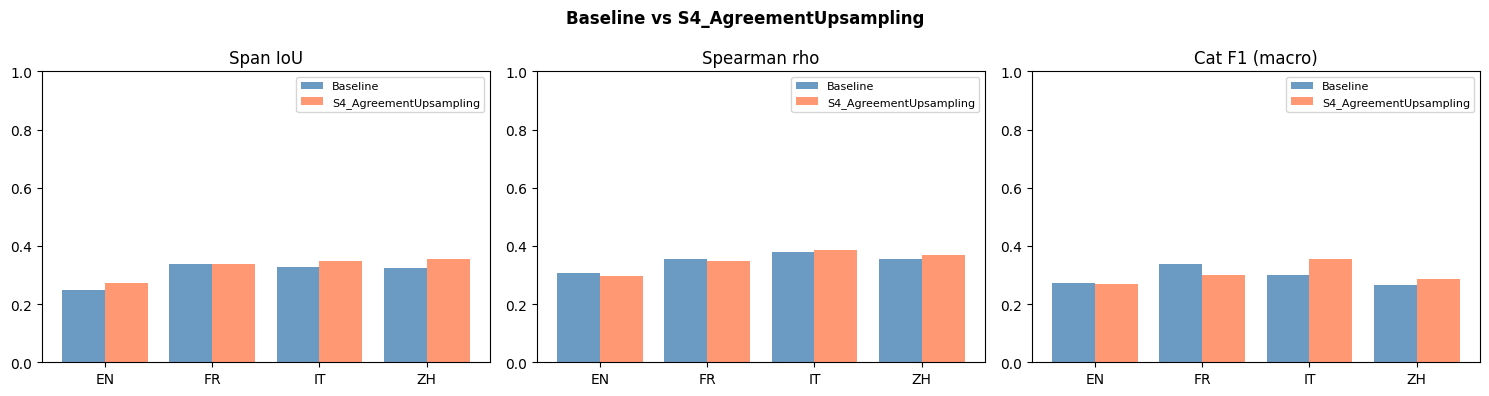

In [ ]:
# ── Compare against baseline ───────────────────────────────────────────────────
if BASELINE_CSV.exists():
    baseline_df = pd.read_csv(BASELINE_CSV)
    print('=' * 70)
    print(f'COMPARISON: Baseline (real only)  vs  {STRATEGY}')
    print('=' * 70)

    metrics = ['Span IoU', 'Spearman rho', 'Cat F1 (macro)']
    # Normalize column name for Spearman
    if 'Spearman \u03c1' in baseline_df.columns:
        baseline_df = baseline_df.rename(columns={'Spearman \u03c1': 'Spearman rho'})

    comparison_rows = []
    for _, brow in baseline_df.iterrows():
        lang = brow['Language']
        aug_row = results_df[results_df['Language'] == lang]
        if aug_row.empty: continue
        aug_row = aug_row.iloc[0]
        row = {'Language': lang}
        for m in metrics:
            bval = float(brow[m]) if m in brow else 0.0
            aval = float(aug_row[m]) if m in aug_row.index else 0.0
            delta = aval - bval
            sign = '+' if delta >= 0 else ''
            row[f'{m} (base)'] = f'{bval:.4f}'
            row[f'{m} ({STRATEGY})'] = f'{aval:.4f}'
            row[f'{m} Δ'] = f'{sign}{delta:.4f}'
        comparison_rows.append(row)

    cmp_df = pd.DataFrame(comparison_rows)
    print(cmp_df.to_string(index=False))
    cmp_df.to_csv(OUTPUT_DIR / f'comparison_vs_baseline_{STRATEGY}.csv', index=False)

    # Bar chart: IoU baseline vs augmented
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    langs_plot = [r['Language'] for r in comparison_rows if r['Language'] != 'OVERALL']
    for ax, metric in zip(axes, metrics):
        base_vals = [float(baseline_df[baseline_df['Language']==l][metric].values[0]) for l in langs_plot]
        aug_vals  = [float(results_df[results_df['Language']==l][metric].values[0]) for l in langs_plot]
        x = np.arange(len(langs_plot))
        ax.bar(x-0.2, base_vals, 0.4, label='Baseline', color='steelblue', alpha=0.8)
        ax.bar(x+0.2, aug_vals,  0.4, label=STRATEGY, color='coral', alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels(langs_plot)
        ax.set_title(metric); ax.set_ylim(0, 1); ax.legend(fontsize=8)
    plt.suptitle(f'Baseline vs {STRATEGY}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'comparison_chart.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'baseline_results.csv not found at {BASELINE_CSV}')
    print('Run Finetune_Multimodal_RealData.ipynb first to generate baseline.')